<a href="https://colab.research.google.com/github/vikash-mahar/AI-MLNotes/blob/main/29ZeroInitializationRelu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving random.csv to random.csv


In [3]:
df = pd.read_csv('random.csv')

In [4]:
df.head()

,feature1,feature2,label
0,0.374540,0.969585,0
1,0.950714,0.775133,1
2,0.731994,0.939499,0
3,0.598658,0.894827,0
4,0.156019,0.597900,1


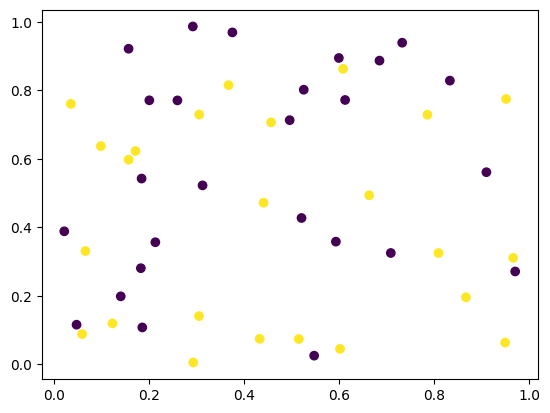

In [5]:
plt.scatter(df['feature1'],df['feature2'],c=df['label'])

In [6]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [8]:
model = Sequential()

model.add(Dense(2,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Set parameters to 0
model.get_weights()

[array([[-0.6933458 ,  0.29196286],
        [ 0.2750486 ,  0.4870032 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.34363568],
        [-0.09017539]], dtype=float32),
 array([0.], dtype=float32)]

In [10]:
initial_weights = model.get_weights()

In [11]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [12]:
model.set_weights(initial_weights)

In [13]:
model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [15]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.5271 - loss: 0.8410 - val_accuracy: 0.3000 - val_loss: 1.1116
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5375 - loss: 0.8252 - val_accuracy: 0.3000 - val_loss: 1.1090
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5375 - loss: 0.8240 - val_accuracy: 0.3000 - val_loss: 1.1064
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4958 - loss: 0.8752 - val_accuracy: 0.3000 - val_loss: 1.1041
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5062 - loss: 0.8598 - val_accuracy: 0.3000 - val_loss: 1.1020
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5271 - loss: 0.8343 - val_accuracy: 0.3000 - val_loss: 1.0999
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5479 - loss: 0.8078 - val_accuracy: 0.3000 - val_loss: 1.0978
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5167 - loss: 0.8437 - val_accuracy: 0.3000 - val_loss

In [16]:
model.get_weights()

[array([[0.36465788, 0.36465788],
        [0.33136103, 0.33136103]], dtype=float32),
 array([0.3435514, 0.3435514], dtype=float32),
 array([[0.33711582],
        [0.33711582]], dtype=float32),
 array([0.33428353], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

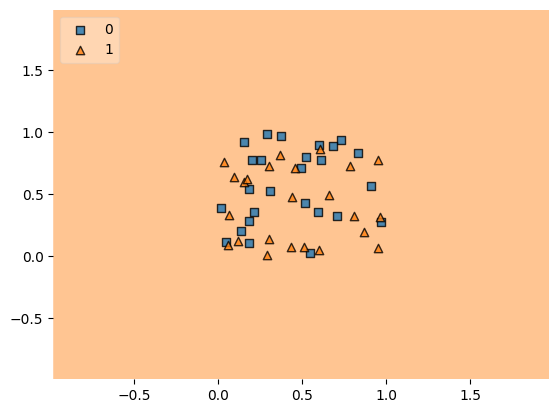

In [17]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)